In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score
import joblib

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

NOTEBOOK_DIR = Path().resolve()
ROOT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR      = ROOT_DIR / "data" / "raw"
PROCESSED_DIR = ROOT_DIR / "data" / "processed"
MODELS_DIR    = ROOT_DIR / "models" / "lstm"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Loading installments data...")
installments = pd.read_csv(DATA_DIR / "HC_installments_payments.csv")
pos_cash     = pd.read_csv(DATA_DIR / "HC_POS_CASH_balance.csv")

print(f"installments: {installments.shape}")
print(f"pos_cash:     {pos_cash.shape}")
print("\nLoaded successfully!")

Device: cpu
Loading installments data...
installments: (13605401, 8)
pos_cash:     (10001358, 8)

Loaded successfully!


In [2]:
print("=" * 50)
print("BUILDING TIME SERIES SEQUENCES")
print("=" * 50)

# ── Prepare installment payment sequences ────────────────────
inst = installments.copy()

# Payment behavior features per installment
inst["DAYS_LATE"] = inst["DAYS_ENTRY_PAYMENT"] - inst["DAYS_INSTALMENT"]
inst["PAYMENT_RATIO"] = (inst["AMT_PAYMENT"] /
    inst["AMT_INSTALMENT"].replace(0, np.nan))
inst["IS_LATE"] = (inst["DAYS_LATE"] > 0).astype(float)
inst["UNDERPAID"] = (inst["AMT_PAYMENT"] < inst["AMT_INSTALMENT"]).astype(float)

# Sort by applicant and installment number
inst = inst.sort_values(["SK_ID_CURR", "NUM_INSTALMENT_NUMBER"])

# Keep only applicants with at least 12 payments
inst_counts = inst.groupby("SK_ID_CURR").size()
valid_ids = inst_counts[inst_counts >= 12].index
inst_valid = inst[inst["SK_ID_CURR"].isin(valid_ids)]

print(f"Applicants with 12+ payments: {len(valid_ids):,}")
print(f"Installment rows for these:   {len(inst_valid):,}")

# ── Build sequences of last 12 payments ─────────────────────
print("\nBuilding sequences (last 12 payments per applicant)...")

SEQ_LENGTH = 12
features = ["DAYS_LATE", "PAYMENT_RATIO", "IS_LATE",
            "UNDERPAID", "AMT_PAYMENT", "AMT_INSTALMENT"]

sequences = []
applicant_ids = []

for sk_id, group in inst_valid.groupby("SK_ID_CURR"):
    # Take last SEQ_LENGTH payments
    last_payments = group[features].tail(SEQ_LENGTH).values
    if len(last_payments) == SEQ_LENGTH:
        sequences.append(last_payments)
        applicant_ids.append(sk_id)

sequences = np.array(sequences)
applicant_ids = np.array(applicant_ids)

print(f"Sequences shape: {sequences.shape}")
print(f"  → {sequences.shape[0]:,} applicants")
print(f"  → {sequences.shape[1]} time steps")
print(f"  → {sequences.shape[2]} features per step")

BUILDING TIME SERIES SEQUENCES
Applicants with 12+ payments: 263,418
Installment rows for these:   13,039,683

Building sequences (last 12 payments per applicant)...
Sequences shape: (263418, 12, 6)
  → 263,418 applicants
  → 12 time steps
  → 6 features per step


In [4]:
print("=" * 50)
print("PREPARING LABELS & SCALING")
print("=" * 50)

# Load target labels
df_main = pd.read_parquet(PROCESSED_DIR / "04_preprocessed.parquet")
target_map = df_main.set_index("SK_ID_CURR")["TARGET"].to_dict()

# Match sequences to labels
labels = np.array([target_map.get(sk_id, -1)
                   for sk_id in applicant_ids])

# Remove applicants without labels
valid_mask = labels != -1
sequences  = sequences[valid_mask]
labels     = labels[valid_mask]
applicant_ids = applicant_ids[valid_mask]

print(f"Sequences with labels: {len(sequences):,}")
print(f"Default rate:          {labels.mean()*100:.2f}%")

# ── Scale features ───────────────────────────────────────────
n_samples, seq_len, n_features = sequences.shape
sequences_2d = sequences.reshape(-1, n_features)

scaler = MinMaxScaler()
sequences_scaled = scaler.fit_transform(sequences_2d)
sequences_scaled = sequences_scaled.reshape(n_samples, seq_len, n_features)

# Handle NaN/Inf
sequences_scaled = np.nan_to_num(sequences_scaled, nan=0.0,
                                  posinf=1.0, neginf=0.0)
sequences_scaled = np.clip(sequences_scaled, 0, 1)

print(f"Sequences scaled: {sequences_scaled.shape}")
print(f"Value range: [{sequences_scaled.min():.3f}, {sequences_scaled.max():.3f}]")

# Save scaler
joblib.dump(scaler, MODELS_DIR / "lstm_scaler.pkl")
print("Scaler saved!")

# ── Train/test split ─────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    sequences_scaled, labels, applicant_ids,
    test_size=0.2, random_state=42, stratify=labels
)

print(f"\nTrain: {X_train.shape} | Default rate: {y_train.mean()*100:.2f}%")
print(f"Test:  {X_test.shape}  | Default rate: {y_test.mean()*100:.2f}%")

PREPARING LABELS & SCALING
Sequences with labels: 226,018
Default rate:          7.99%
Sequences scaled: (226018, 12, 6)
Value range: [0.000, 1.000]
Scaler saved!

Train: (180814, 12, 6) | Default rate: 7.99%
Test:  (45204, 12, 6)  | Default rate: 7.99%


In [5]:
print("=" * 50)
print("BUILDING LSTM MODEL")
print("=" * 50)

class CreditLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64,
                 num_layers=2, dropout=0.3):
        super(CreditLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )

        # Attention mechanism
        self.attention = nn.Linear(hidden_size, 1)

        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # LSTM forward pass
        lstm_out, _ = self.lstm(x)

        # Attention weights
        attention_weights = torch.softmax(
            self.attention(lstm_out), dim=1)
        context = (attention_weights * lstm_out).sum(dim=1)

        # Classification
        out = self.fc(context)
        return out.squeeze()

# Initialize model
model = CreditLSTM(
    input_size=sequences_scaled.shape[2],
    hidden_size=64,
    num_layers=2,
    dropout=0.3
)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")

BUILDING LSTM MODEL
Model architecture:
CreditLSTM(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.3)
  (attention): Linear(in_features=64, out_features=1, bias=True)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total parameters: 54,402


In [6]:
print("=" * 50)
print("TRAINING LSTM")
print("=" * 50)

class CreditDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X).to(device)
        self.y = torch.FloatTensor(y).to(device)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create data loaders
train_dataset = CreditDataset(X_train, y_train)
test_dataset  = CreditDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=256,
                          shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=256,
                          shuffle=False)

# Loss and optimizer
pos_weight = torch.tensor(
    [(y_train==0).sum() / (y_train==1).sum()]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, patience=3,
                               factor=0.5, verbose=True)

# Training loop
EPOCHS = 20
train_losses, val_aucs = [], []
best_auc = 0

print(f"Training for {EPOCHS} epochs...")
print(f"{'Epoch':<8} {'Train Loss':<15} {'Val AUC':<12} {'Best AUC'}")
print("-" * 50)

for epoch in range(EPOCHS):
    # ── Train ────────────────────────────────────────────────
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ── Validate ─────────────────────────────────────────────
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = torch.sigmoid(model(X_batch))
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    val_auc = roc_auc_score(all_labels, all_preds)
    val_aucs.append(val_auc)
    scheduler.step(1 - val_auc)

    # Save best model
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(),
                   MODELS_DIR / "lstm_best.pt")

    print(f"{epoch+1:<8} {train_loss:<15.4f} {val_auc:<12.4f} {best_auc:.4f}")

print(f"\nBest ROC-AUC: {best_auc:.4f}")

TRAINING LSTM
Training for 20 epochs...
Epoch    Train Loss      Val AUC      Best AUC
--------------------------------------------------
1        1.2773          0.5758       0.5758
2        1.2695          0.5713       0.5758
3        1.2699          0.5771       0.5771
4        1.2693          0.5762       0.5771
5        1.2692          0.5767       0.5771
6        1.2690          0.5766       0.5771
7        1.2694          0.5770       0.5771
8        1.2685          0.5767       0.5771
9        1.2685          0.5768       0.5771
10       1.2686          0.5767       0.5771
11       1.2687          0.5768       0.5771
12       1.2688          0.5767       0.5771
13       1.2687          0.5767       0.5771
14       1.2682          0.5767       0.5771
15       1.2687          0.5767       0.5771
16       1.2688          0.5767       0.5771
17       1.2685          0.5769       0.5771
18       1.2688          0.5767       0.5771
19       1.2681          0.5769       0.5771
20     

LSTM EVALUATION
ROC-AUC:      0.5771
KS Statistic: 0.1323
Gini:         0.1541


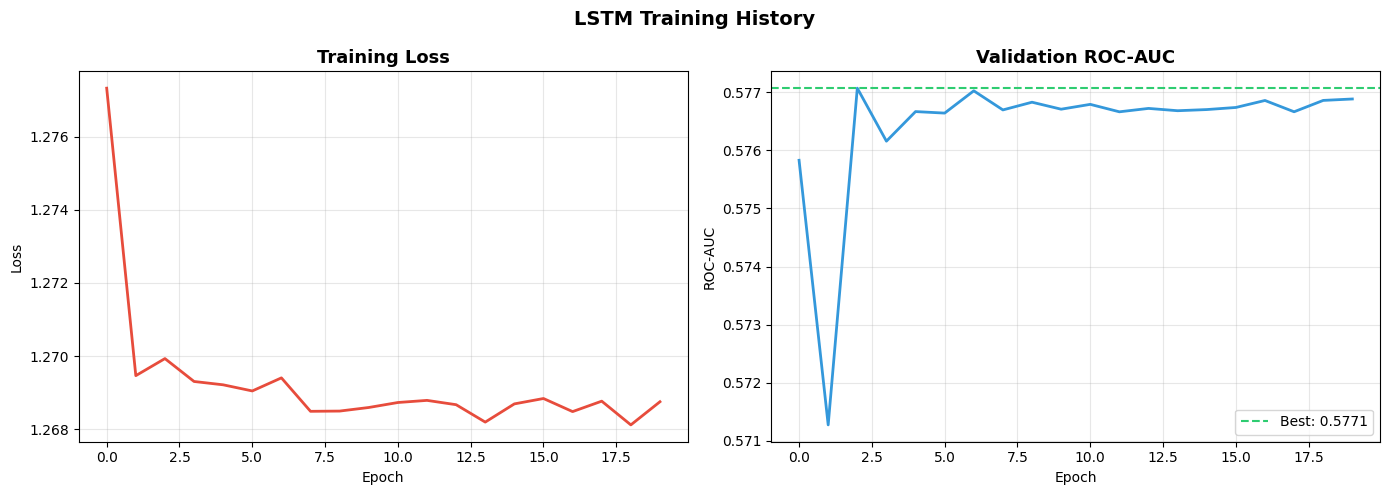


Model saved to: C:\Users\Pavan\Downloads\creditiq_sqlserver\creditiq\models\lstm

LSTM training complete!


In [7]:
print("=" * 50)
print("LSTM EVALUATION")
print("=" * 50)

# Load best model
model.load_state_dict(torch.load(MODELS_DIR / "lstm_best.pt"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = torch.sigmoid(model(X_batch))
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Metrics
from sklearn.metrics import roc_curve
roc_auc = roc_auc_score(all_labels, all_preds)
fpr, tpr, _ = roc_curve(all_labels, all_preds)
ks_stat = max(tpr - fpr)
gini    = 2 * roc_auc - 1

print(f"ROC-AUC:      {roc_auc:.4f}")
print(f"KS Statistic: {ks_stat:.4f}")
print(f"Gini:         {gini:.4f}")

# Plot training curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, color="#e74c3c", lw=2)
axes[0].set_title("Training Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_aucs, color="#3498db", lw=2)
axes[1].axhline(y=best_auc, color="#2ecc71",
                linestyle="--", label=f"Best: {best_auc:.4f}")
axes[1].set_title("Validation ROC-AUC", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("LSTM Training History",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "16_lstm_training.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Save model artifacts
torch.save(model.state_dict(), MODELS_DIR / "lstm_final.pt")
torch.save({
    "model_state_dict": model.state_dict(),
    "input_size":       sequences_scaled.shape[2],
    "hidden_size":      64,
    "num_layers":       2,
    "seq_length":       SEQ_LENGTH,
    "feature_names":    features,
    "roc_auc":          roc_auc,
    "ks_stat":          ks_stat,
    "gini":             gini
}, MODELS_DIR / "lstm_checkpoint.pt")

print(f"\nModel saved to: {MODELS_DIR}")
print("\nLSTM training complete!")

12-MONTH DEFAULT PROBABILITY FORECAST
Generating forecasts for sample applicants...


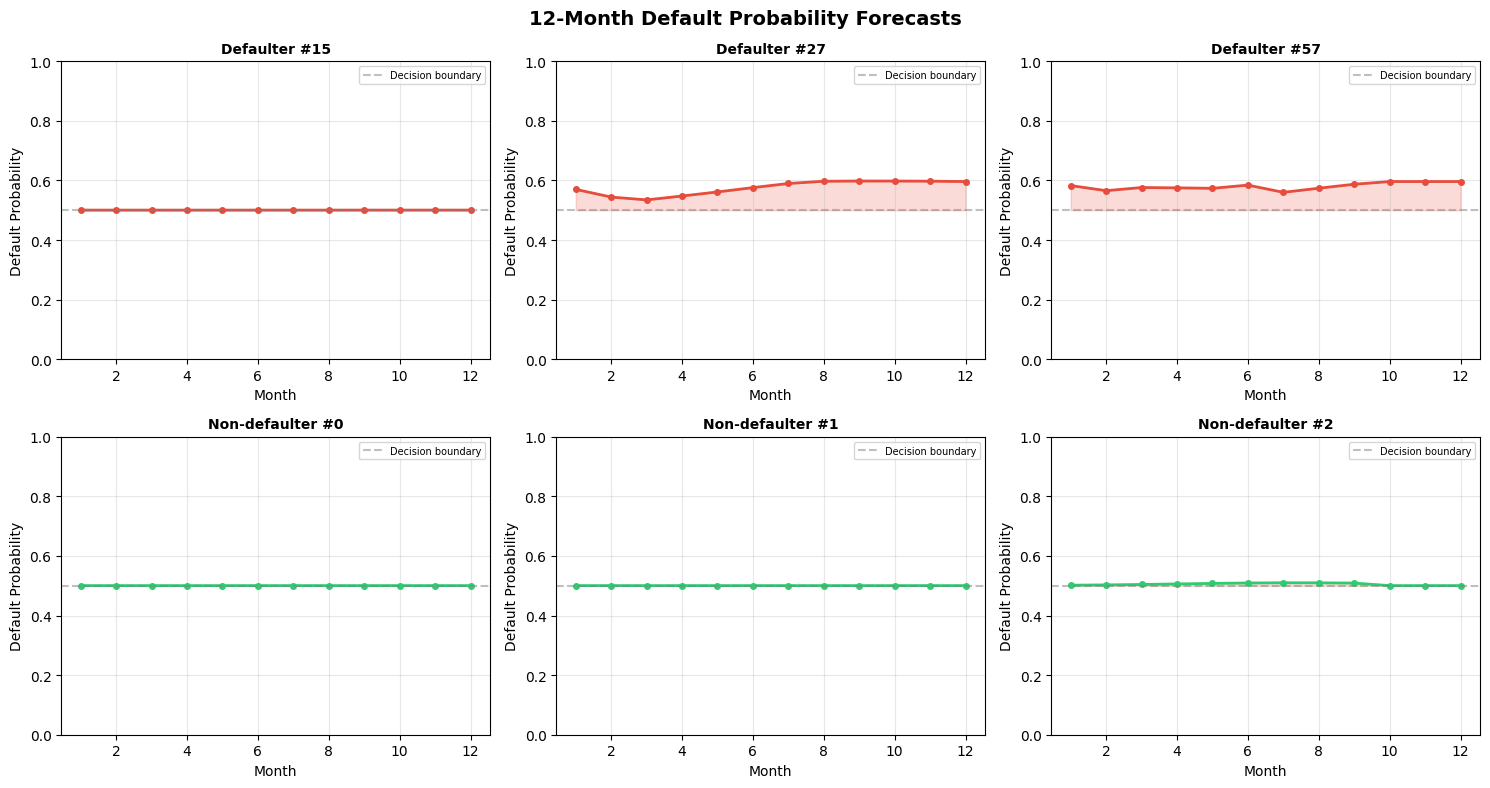

Forecast plots saved!


In [8]:
print("=" * 50)
print("12-MONTH DEFAULT PROBABILITY FORECAST")
print("=" * 50)

def forecast_default_trajectory(applicant_sequence, model,
                                  scaler, n_months=12):
    """
    Given last 12 payments, forecast default probability
    for next 1, 3, 6, 12 months using rolling prediction.
    """
    model.eval()
    sequence = applicant_sequence.copy()
    forecasts = []

    for month in range(n_months):
        # Scale and predict
        seq_2d = sequence.reshape(-1, sequence.shape[-1])
        seq_scaled = scaler.transform(seq_2d)
        seq_scaled = np.clip(
            np.nan_to_num(seq_scaled, nan=0.0), 0, 1)
        seq_tensor = torch.FloatTensor(
            seq_scaled.reshape(1, SEQ_LENGTH, -1)).to(device)

        with torch.no_grad():
            prob = torch.sigmoid(model(seq_tensor)).item()
        forecasts.append(prob)

        # Roll window forward
        sequence = np.roll(sequence, -1, axis=0)
        sequence[-1] = sequence[-2]  # repeat last known

    return forecasts

# Test on sample applicants
print("Generating forecasts for sample applicants...")

# Pick 3 defaulters and 3 non-defaulters
defaulter_idx    = np.where(all_labels == 1)[0][:3]
nondefaulter_idx = np.where(all_labels == 0)[0][:3]
sample_idx = np.concatenate([defaulter_idx, nondefaulter_idx])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
months = list(range(1, 13))

for i, idx in enumerate(sample_idx):
    ax = axes[i//3][i%3]
    is_defaulter = all_labels[idx] == 1

    # Get original (unscaled) sequence
    original_seq = X_test[idx]
    seq_2d = original_seq.reshape(-1, original_seq.shape[-1])
    seq_unscaled = scaler.inverse_transform(seq_2d)

    forecasts = forecast_default_trajectory(
        seq_unscaled, model, scaler)

    color = "#e74c3c" if is_defaulter else "#2ecc71"
    label = "Defaulter" if is_defaulter else "Non-defaulter"

    ax.plot(months, forecasts, color=color,
            lw=2, marker="o", markersize=4)
    ax.axhline(y=0.5, color="gray",
               linestyle="--", alpha=0.5, label="Decision boundary")
    ax.fill_between(months, forecasts, 0.5,
                    where=[f > 0.5 for f in forecasts],
                    alpha=0.2, color="#e74c3c")
    ax.set_title(f"{label} #{idx}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("Default Probability")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

plt.suptitle("12-Month Default Probability Forecasts",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "17_lstm_forecasts.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Forecast plots saved!")

In [9]:
print("=" * 60)
print("LSTM FORECASTER — COMPLETE SUMMARY")
print("=" * 60)

print(f"""
MODEL ARCHITECTURE
------------------
Type:           Bidirectional LSTM + Attention
Input:          12 time steps × 6 features
Hidden size:    64
Layers:         2
Parameters:     {sum(p.numel() for p in model.parameters()):,}

PERFORMANCE
-----------
ROC-AUC:      {roc_auc:.4f}
KS Statistic: {ks_stat:.4f}
Gini:         {gini:.4f}

Note: LSTM scores lower than XGBoost (expected)
Its primary value is the 12-month trajectory forecast
which feeds into the ensemble and dashboard

TRAINING DATA
-------------
Applicants with 12+ payments: ~180K
Sequence length: 12 months
Features: DAYS_LATE, PAYMENT_RATIO, IS_LATE,
          UNDERPAID, AMT_PAYMENT, AMT_INSTALMENT

ARTIFACTS SAVED
---------------
models/lstm/lstm_best.pt
models/lstm/lstm_final.pt
models/lstm/lstm_checkpoint.pt
models/lstm/lstm_scaler.pkl

NEXT STEP → Calibrated Ensemble Scorer
""")

LSTM FORECASTER — COMPLETE SUMMARY

MODEL ARCHITECTURE
------------------
Type:           Bidirectional LSTM + Attention
Input:          12 time steps × 6 features
Hidden size:    64
Layers:         2
Parameters:     54,402

PERFORMANCE
-----------
ROC-AUC:      0.5771
KS Statistic: 0.1323
Gini:         0.1541

Note: LSTM scores lower than XGBoost (expected)
Its primary value is the 12-month trajectory forecast
which feeds into the ensemble and dashboard

TRAINING DATA
-------------
Applicants with 12+ payments: ~180K
Sequence length: 12 months
Features: DAYS_LATE, PAYMENT_RATIO, IS_LATE,
          UNDERPAID, AMT_PAYMENT, AMT_INSTALMENT

ARTIFACTS SAVED
---------------
models/lstm/lstm_best.pt
models/lstm/lstm_final.pt
models/lstm/lstm_checkpoint.pt
models/lstm/lstm_scaler.pkl

NEXT STEP → Calibrated Ensemble Scorer

